# Medical Insurance Cost Prediction (Regression)

## Introduction

This dataset is commonly sourced from public repositories such as Kaggle and contains information about individuals' demographics and health-related attributes. The objective is to predict medical insurance charges using supervised learning (regression).

### Purpose
This dataset is used to model and understand how factors such as age, BMI, smoking status, and region affect insurance costs. It is relevant for risk assessment, pricing strategies, and customer segmentation in the insurance industry.

### Limitations
- Relatively small dataset (~2700 rows)
- Limited number of predictors
- Potential bias (e.g., underrepresentation of populations)

### Justification
This dataset is well suited for regression tasks due to a continuous target variable (charges) and a mix of categorical and numerical predictors.


## Setup and Data Loading

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/TABxSAID/Datasets/refs/heads/master/medical_insurance.csv')

# Display basic info
print("Dataset shape:", df.shape)
df.head()

# Set Seaborn theme with HUSL palette
sns.set_theme(style="whitegrid", palette="husl")



Dataset shape: (2772, 7)


## Milestone 1: Data Understanding and Quality Assessment

### 1) Data Types Identification

In [2]:
# Data types
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [3]:
# Variable classification
print("""
Variable Classification:
- age          : continuous (integer)
- sex          : categorical nominal (male/female)
- bmi          : continuous (float)
- children     : discrete (can be treated as numeric)
- smoker       : categorical nominal (yes/no)
- region       : categorical nominal (4 regions)
- charges      : continuous (target)
""")


Variable Classification:
- age          : continuous (integer)
- sex          : categorical nominal (male/female)
- bmi          : continuous (float)
- children     : discrete (can be treated as numeric)
- smoker       : categorical nominal (yes/no)
- region       : categorical nominal (4 regions)
- charges      : continuous (target)



### 2) Data Quality Assessment

We check for missing values, duplicates, outliers, and inconsistent entries.

In [4]:
# Missing values
missing = df.isnull().sum()
print("Missing values per column:\n", missing)
if missing.sum() == 0:
    print("\n No missing values found.")
else:
    print("\n Missing values present. Consider imputation.")

Missing values per column:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

 No missing values found.


In [5]:
# Duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print("\nFirst few duplicates:")
    print(df[df.duplicated(keep=False)].head())
    # Remove duplicates
    df = df.drop_duplicates()
    print(f"\n Duplicates removed. New shape: {df.shape}")
else:
    print("\n No duplicate rows found.")

Number of duplicate rows: 1435

First few duplicates:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

 Duplicates removed. New shape: (1337, 7)


age: 0 outliers
bmi: 9 outliers
children: 0 outliers
charges: 139 outliers


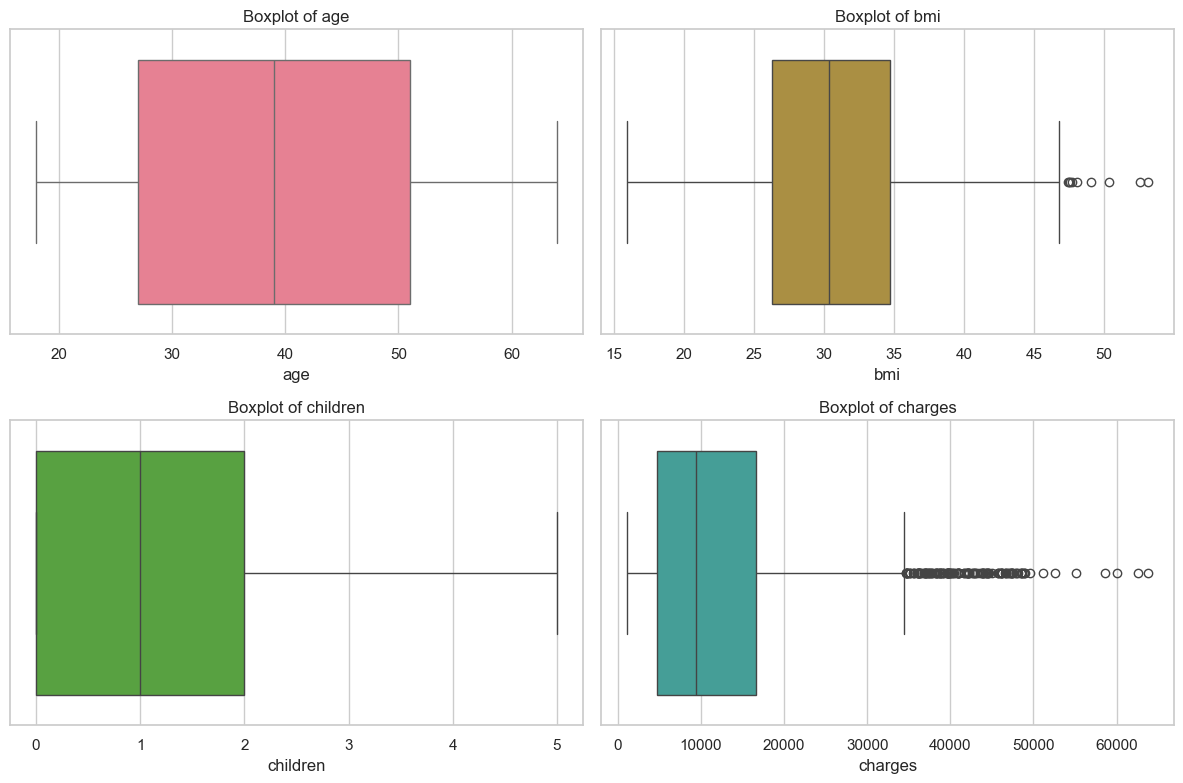

In [6]:
# Outlier detection using IQR method
numeric_cols = ['age', 'bmi', 'children', 'charges']
outlier_counts = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_counts[col] = len(outliers)
    print(f"{col}: {len(outliers)} outliers")

# Visual inspection
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(numeric_cols):
    ax = axes[i//2, i%2]
    sns.boxplot(x=df[col], ax=ax, color=sns.color_palette("husl")[i])
    ax.set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

**Observation:** charges have many high values (true for high-risk individuals).

**Note:** we keep outliers but will later apply log transformation to reduce skewness.

In [7]:
# Check categorical values for consistency
cat_cols = ['sex', 'smoker', 'region']
for col in cat_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].value_counts())


Unique values in sex:
sex
male      675
female    662
Name: count, dtype: int64

Unique values in smoker:
smoker
no     1063
yes     274
Name: count, dtype: int64

Unique values in region:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


**Data Quality Summary**
- No missing values.
- Duplicates removed.
- Outliers exist but are plausible; we will keep them.
- Categorical values are consistent.

## Milestone 2: Exploratory Data Analysis and Preprocessing

### 1) Exploratory Data Analysis (EDA)

We compute summary statistics and generate visualizations.

In [8]:
# Summary statistics for numerical columns
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


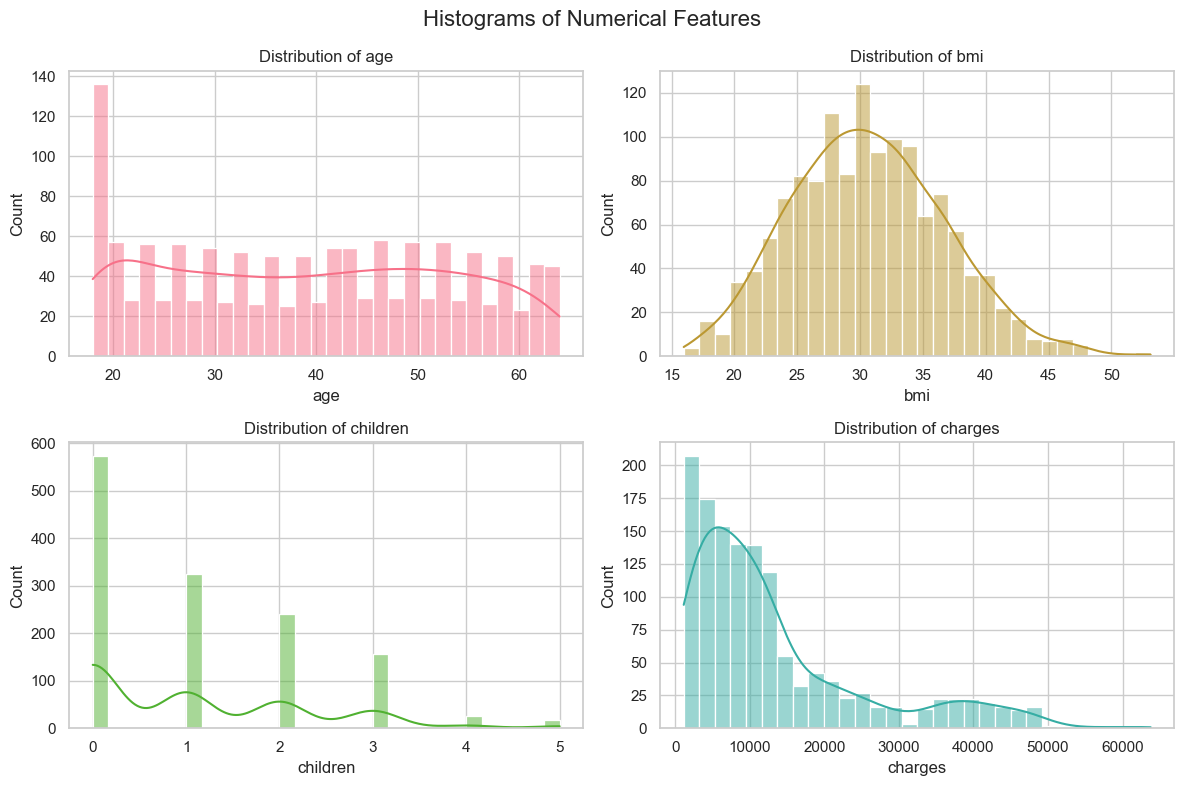

In [9]:
# Histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(['age', 'bmi', 'children', 'charges']):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i],
                 color=sns.color_palette("husl")[i])
    axes[i].set_title(f'Distribution of {col}')

plt.suptitle('Histograms of Numerical Features', size=16)
plt.tight_layout()
plt.show()

**Observation:** charges is heavily right-skewed, therefore a log transformation recommended.

C:\Users\007\AppData\Local\Temp\ipykernel_8308\3083257258.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='charges', data=df,
C:\Users\007\AppData\Local\Temp\ipykernel_8308\3083257258.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='charges', data=df,
C:\Users\007\AppData\Local\Temp\ipykernel_8308\3083257258.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='charges', data=df,


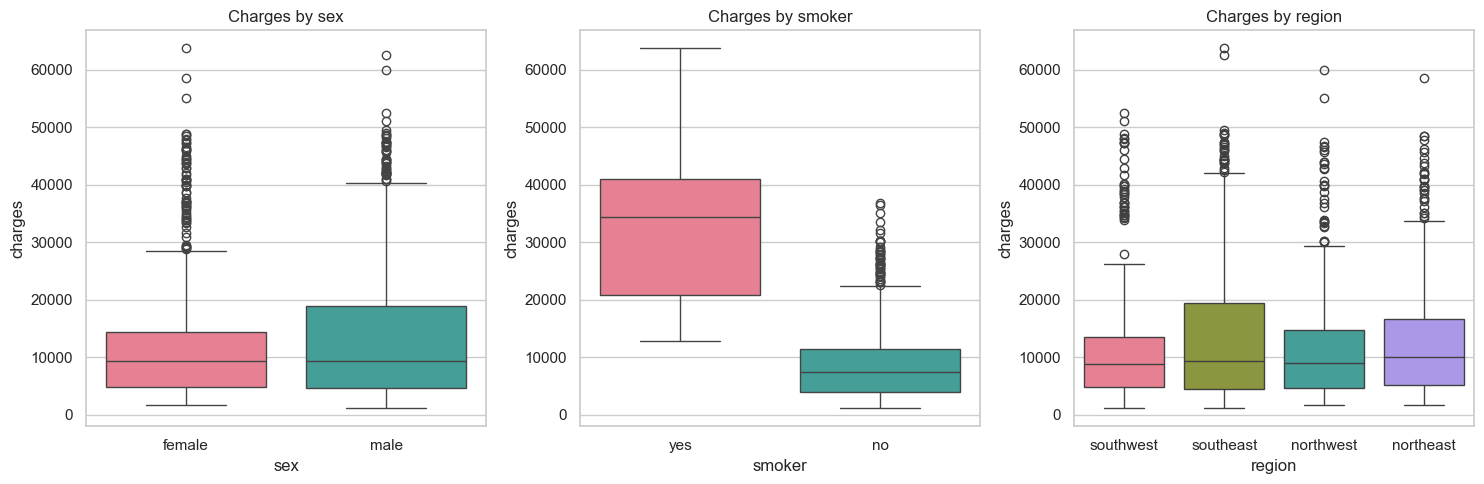

In [10]:
# Boxplots of charges by categorical variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols):
    sns.boxplot(x=col, y='charges', data=df,
                ax=axes[i],
                palette="husl")
    axes[i].set_title(f'Charges by {col}')

plt.tight_layout()
plt.show()

**Observation:** smokers have much higher charges; sex and region differences are smaller.

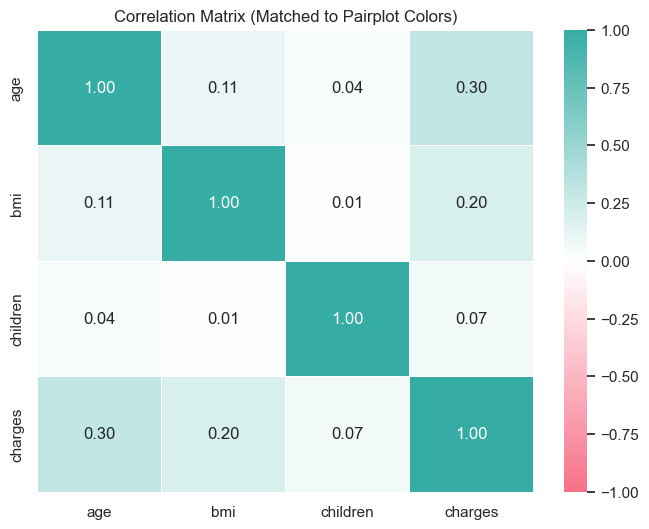

In [11]:
# Correlation matrix for numerical features
num_df = df[['age', 'bmi', 'children', 'charges']]
corr = num_df.corr()

# Heatmap
from matplotlib.colors import LinearSegmentedColormap
pink = "#f77189"
green = "#36ada4"

cmap = LinearSegmentedColormap.from_list(
    "custom_pink_green",
    [pink, "white", green]
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap=cmap,
    fmt='.2f',
    linewidths=0.5,
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Correlation Matrix (Matched to Pairplot Colors)')
plt.show()

**Observation:** age and charges have moderate positive correlation; bmi and children weaker.

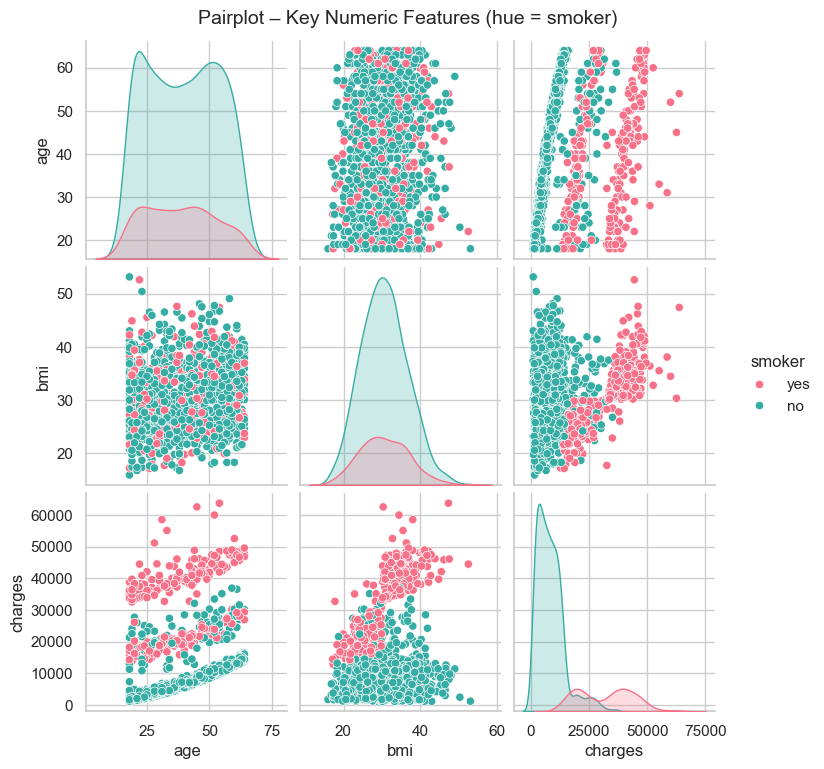

In [12]:
# Pairplot
sns.pairplot(df, hue='smoker', vars=['age','bmi','charges'], palette='husl', diag_kind='kde')
plt.suptitle('Pairplot – Key Numeric Features (hue = smoker)', y=1.02, fontsize=14)
plt.show()

C:\Users\007\AppData\Local\Temp\ipykernel_8308\1606299103.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='region', data=df, ax=axes[0], palette="husl")
C:\Users\007\AppData\Local\Temp\ipykernel_8308\1606299103.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='smoker', data=df, ax=axes[1], palette="husl")


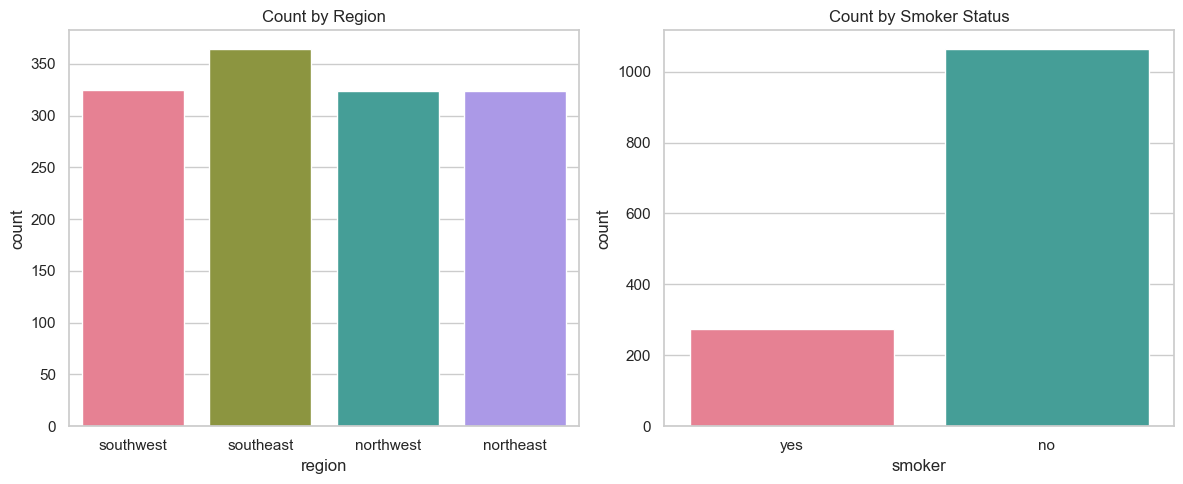

In [13]:
# Count plots for region and smoker
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='region', data=df, ax=axes[0], palette="husl")
axes[0].set_title('Count by Region')

sns.countplot(x='smoker', data=df, ax=axes[1], palette="husl")
axes[1].set_title('Count by Smoker Status')

plt.tight_layout()
plt.show()

### 2) Data Transformation

We will:
- One‑hot encode categorical variables (dropping one to avoid collinearity).
- Apply log transformation to the target variable `charges`.
- Standardize numerical features.

In [14]:
# Copy the cleaned dataframe
df_processed = df.copy()

# One‑hot encoding
df_processed = pd.get_dummies(df_processed, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)

# Show new columns
print("Columns after one-hot encoding:")
df_processed.head()

Columns after one-hot encoding:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


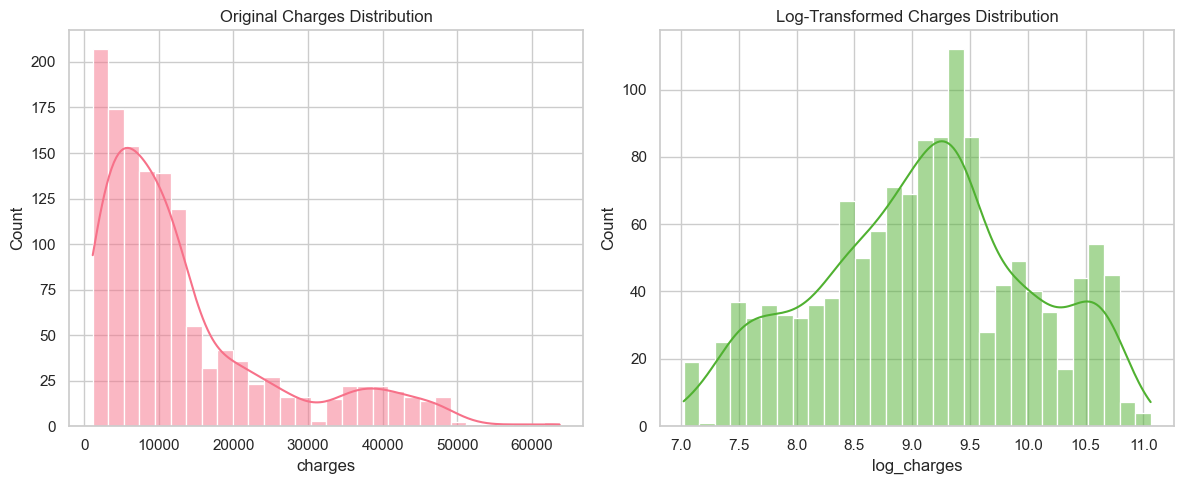

In [15]:
# Log transformation of charges
df_processed['log_charges'] = np.log(df_processed['charges'])

# Visualize the transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_processed['charges'], bins=30, kde=True,
             ax=axes[0], color=sns.color_palette("husl")[0])
axes[0].set_title('Original Charges Distribution')

sns.histplot(df_processed['log_charges'], bins=30, kde=True,
             ax=axes[1], color=sns.color_palette("husl")[2])
axes[1].set_title('Log-Transformed Charges Distribution')

plt.tight_layout()
plt.show()

In [16]:
# Standardize numerical features
from sklearn.preprocessing import StandardScaler

num_features = ['age', 'bmi', 'children']
scaler = StandardScaler()
df_processed[num_features] = scaler.fit_transform(df_processed[num_features])

# Check means and stds
print("Means after scaling:\n", df_processed[num_features].mean())
print("\nStandard deviations:\n", df_processed[num_features].std())

Means after scaling:
 age        -6.643070e-17
bmi        -2.285216e-16
children    3.852980e-17
dtype: float64

Standard deviations:
 age         1.000374
bmi         1.000374
children    1.000374
dtype: float64


### 3) Feature Relationships & Reduction

We examine correlations with the log‑transformed target and check for multicollinearity.

In [17]:
# List of all predictor columns after encoding
predictor_cols = ['age', 'bmi', 'children', 'sex_male', 'smoker_yes',
                   'region_northwest', 'region_southeast', 'region_southwest']

# Correlation with log_charges
corr_with_target = df_processed[predictor_cols + ['log_charges']].corr()['log_charges'].drop('log_charges')
print("Correlation with log_charges:\n", corr_with_target.sort_values(ascending=False))

Correlation with log_charges:
 smoker_yes          0.665718
age                 0.526927
children            0.160336
bmi                 0.132822
region_southeast    0.014968
sex_male            0.007009
region_northwest   -0.015425
region_southwest   -0.042473
Name: log_charges, dtype: float64


C:\Users\007\AppData\Local\Temp\ipykernel_8308\512511804.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


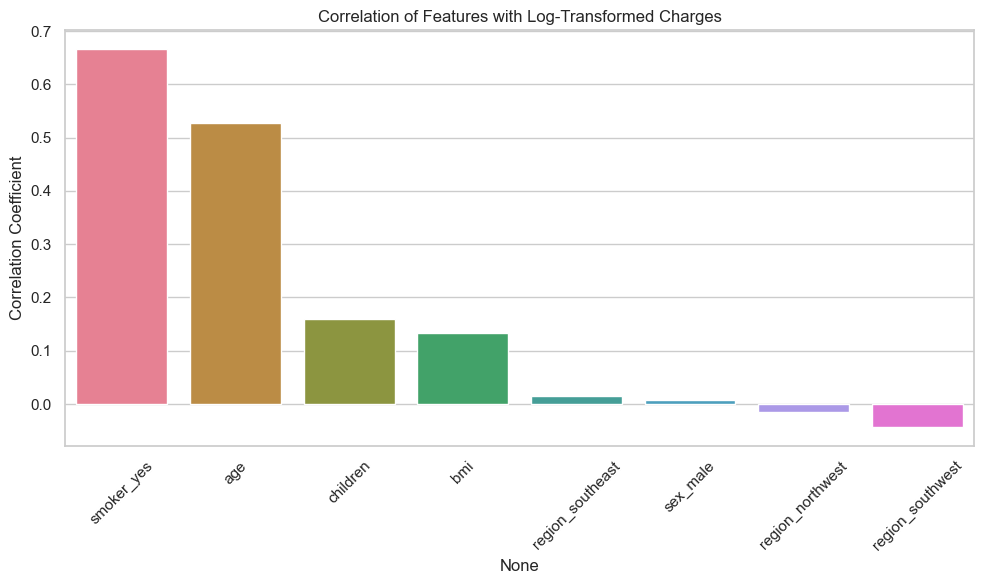

In [18]:
# Bar plot of correlations
plt.figure(figsize=(10, 6))

sns.barplot(
    x=corr_with_target.sort_values(ascending=False).index,
    y=corr_with_target.sort_values(ascending=False).values,
    palette="husl"
)

plt.title('Correlation of Features with Log-Transformed Charges')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

C:\Users\007\AppData\Local\Temp\ipykernel_8308\1653435919.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker_yes', y='log_charges',


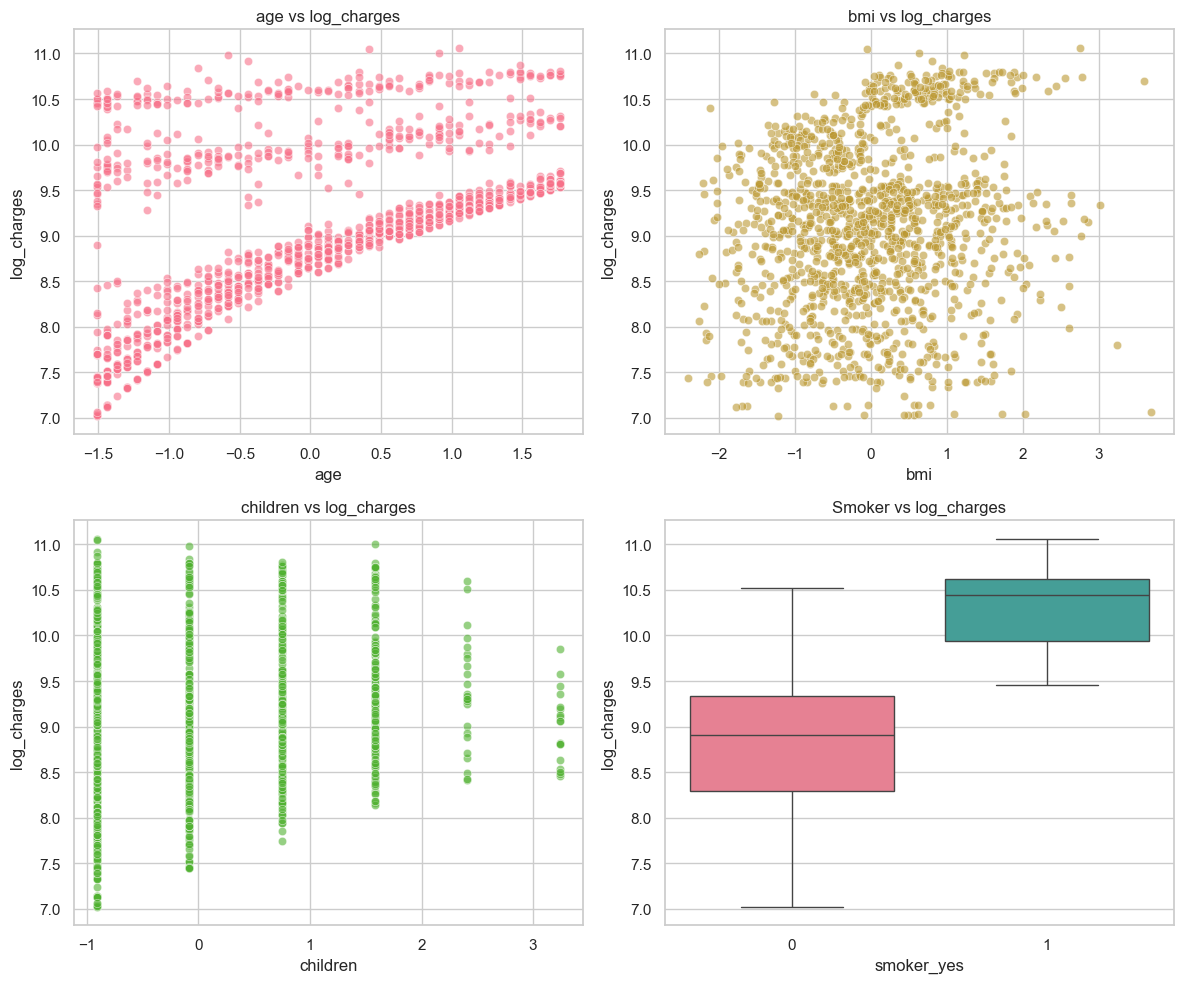

In [19]:
# Scatterplots for continuous predictors vs log_charges
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(['age', 'bmi', 'children']):
    sns.scatterplot(
        x=df_processed[col],
        y=df_processed['log_charges'],
        ax=axes[i],
        color=sns.color_palette("husl")[i],
        alpha=0.6
    )
    axes[i].set_title(f'{col} vs log_charges')

# Boxplot for smoker
sns.boxplot(x='smoker_yes', y='log_charges',
            data=df_processed,
            ax=axes[3],
            palette="husl")

axes[3].set_title('Smoker vs log_charges')

plt.tight_layout()
plt.show()

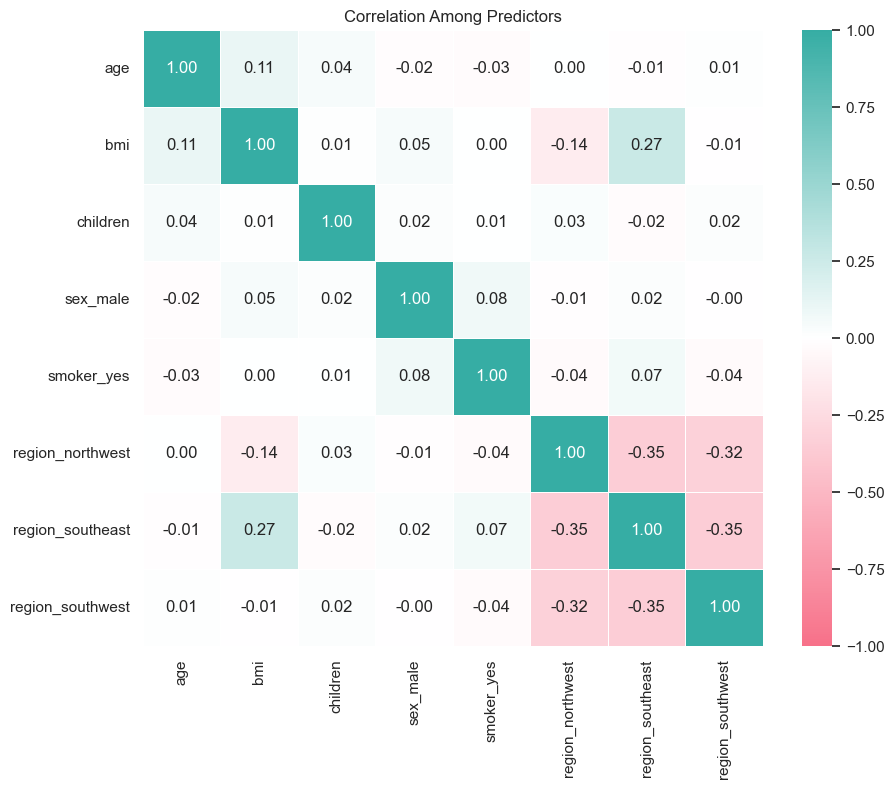

In [20]:
# Check for multicollinearity among predictors
from matplotlib.colors import LinearSegmentedColormap
corr_matrix = df_processed[predictor_cols].corr()

pink = "#f77189"
green = "#36ada4"
cmap = LinearSegmentedColormap.from_list(
    "custom_pink_green",
    [pink, "white", green]
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,   
    annot=True,
    cmap=cmap,
    fmt='.2f',
    linewidths=0.5,
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Correlation Among Predictors')
plt.show()

**Feature Reduction Decision:**
No high correlations (>0.7), multicollinearity is not a concern. Therefore, no dimensionality reduction is needed at this stage. All predictors have been retained. The dataset is now ready for supervised regression modeling.

## Summary of Milestones 1 & 2

- Data types identified and explained.
- Data quality assessed: missing values none, duplicates removed, outliers handled via transformation.
- EDA performed with histograms, boxplots, correlation matrix, and pairplots.
- Data transformation: one-hot encoding, log transformation of target, standardization of numerical features.
- Feature relationships analyzed; no dimensionality reduction necessary.

The cleaned and preprocessed dataset is stored in `df_processed` and can be used for model building in the next phases.